In [79]:
import numpy as np
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
import torch.optim as optim

rng = np.random.default_rng(42)

## Cut-DeepONet - (with exact solution dataset)

-, Step 1: Load data - and Piecewise Cutting \
-, Step 2: Training \
-, Step 3: Cutting Net Loading \
-, Step 4: Test performance & Tracking

#### Step 1: Load data (makes the avoid discontinuity output have the same length)

In [80]:
N_data = 500
data = np.load(f"data/linear_advection_dataset_N_{N_data}.npz", allow_pickle=True)

input_data = data["u0"]
output_data = data["u"]
discon_x_data = data["discontinuities"]
x = data["x"]
t_domain = data["t"]

train_idx = data["train_idx"],
val_idx = data["val_idx"],
test_idx = data["test_idx"]

print("input shape - different u_0:", input_data.shape)
print("output shape - different u_t:", output_data.shape)
print("discontinuity shape:", discon_x_data.shape)
print("x shape:", x.shape)
print("t_domain shape:", t_domain.shape)

input shape - different u_0: (500, 500)
output shape - different u_t: (500, 15, 500)
discontinuity shape: (500, 15, 2)
x shape: (500,)
t_domain shape: (15,)


#### Lift the dimension of coordinate [X, T] -> [X, T, H(X,T)]

In [81]:
# Lifting at the discontinuity locations - check the x sample at the left or right of the discontinuity location at time step t_idx
def H(coords_np, discon_coords):
    discon_1 = discon_coords[:, 0]  # (Nt*Nx,)
    discon_2 = discon_coords[:, 1]  # (Nt*Nx,)
    x = coords_np[:, 0]
    return (x >= discon_1) & (x < discon_2)

N, Nx, Nt = input_data.shape[0], x.shape[0], t_domain.shape[0]

xx, tt = np.meshgrid(x.astype(np.float32), t_domain.astype(np.float32), indexing="xy")
base_coords = np.stack([xx, tt], axis=-1).reshape(-1, 2)  # (Nt*Nx, 2)
coords_np = np.broadcast_to(base_coords[None, :, :], (N, base_coords.shape[0], 2))  # (N, Nt*Nx, 2)

lifted_coords_np = []
for idx in range(N):
    discon_coords = np.tile(discon_x_data[idx], (1, Nx)).reshape(-1,2)  # (Nt*Nx, 2)
    Hx = H(coords_np[idx], discon_coords)  # (Nt*Nx,)
    lifted_coords_np.append(np.concatenate([coords_np[idx], Hx[:, None]], axis=1))  # (Nt*Nx, 3)

lifted_coords_np = np.array(lifted_coords_np)  # (N, Nt*Nx, 3)
print("Lifted coordinates shape:", lifted_coords_np.shape)  # (N, Nt*Nx, 3) [x, t, H(x,t)]

Lifted coordinates shape: (500, 7500, 3)


#### Step 2: Training Cut-DeepONet

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------------------------
# 2) Define Cut-DeepONet
# ---------------------------
class MLP(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, depth=3):
        super().__init__()
        layers = [nn.Linear(in_dim, hidden_dim), nn.Tanh()]
        for _ in range(depth - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.Tanh()]
        layers += [nn.Linear(hidden_dim, out_dim)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

class DeepONet(nn.Module):
    def __init__(self, branch_in, trunk_in=3, latent_dim=128, hidden_dim=256, depth=3):
        super().__init__()
        self.branch = MLP(branch_in, hidden_dim, latent_dim, depth=depth)
        self.trunk = MLP(trunk_in, hidden_dim, latent_dim, depth=depth)
        self.bias = nn.Parameter(torch.zeros(1))

    def forward(self, branch_input, lifted_trunk_input):
        # branch_input: (B, Nx), lifted_trunk_input: (B, P, 2)
        b = self.branch(branch_input)      # (B, latent)
        # Trunk with lifted domain input
        t = self.trunk(lifted_trunk_input)     # (B, P, latent)
        y = torch.einsum('bl,bpl->bp', b, t) + self.bias  # (B, P)
        return y

model = DeepONet(branch_in=Nx, latent_dim=128, hidden_dim=256, depth=3).to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-6)
loss_fn = nn.MSELoss()

# ---------------------------
# 3) Train
# ---------------------------
epochs = 500
batch_size = 128 # Have to use batch_size is 1, because each case u_0, we have different location of output sampling. Thus the coords_np have location different for each case [N, Nt*reduced_Nx, 2]
points_per_step = 50  # sampled (x,t) points per batch
train_losses, val_losses = [], []

for epoch in range(1, epochs + 1):
    model.train()
    rng.shuffle(train_idx)
    epoch_loss = 0.0
    n_batches = 0

    for start in range(0, len(train_idx), batch_size):
        # Input and Output for the current batch
        batched_idx = train_idx[start:start + batch_size] 
        batched_input = torch.tensor(input_data[batched_idx], dtype=torch.float32, device=device)   # (B, Nx)
        batched_output = torch.tensor(output_data[batched_idx], dtype=torch.float32, device=device) # (B, Nt, reduced-Nx)
        batched_x = torch.tensor(lifted_coords_np[batched_idx], dtype=torch.float32, device=device) # (B, Nt, reduced-Nx) - different for each case because of different location of output sampling

        # Randomly sample points in the (Nt,Nx) domain for training - Dont choose the x at the point has been removed
        rng = np.random.default_rng(42)
        point_idx = rng.integers(0, Nx*Nt, size=points_per_step)
        t_idx, x_idx = point_idx // Nx, point_idx % Nx
        # t_idx, x_idx = np.linspace(0, Nt - 1, points_per_step, dtype=int), np.linspace(0, Nx - 1, points_per_step, dtype=int)

        # Trunk input and target output for the sampled points
        lifted_trunk_input = torch.tensor(batched_x[:, point_idx], dtype=torch.float32, device=device)  # (P, 3)
        output_target = torch.tensor(batched_output[:, t_idx, x_idx], dtype=torch.float32, device=device)  # (P, B)

        optimizer.zero_grad()
        output_pred = model(batched_input, lifted_trunk_input)
        loss = loss_fn(output_pred, output_target)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        n_batches += 1

    train_losses.append(epoch_loss / max(n_batches, 1))

    # quick validation (random sampled points)
    model.eval()
    with torch.no_grad():
        batched_val = val_idx if len(val_idx) <= 32 else rng.choice(val_idx, size=32, replace=False)
        batched_input_val = torch.tensor(input_data[batched_val], dtype=torch.float32, device=device)
        batched_output_val = torch.tensor(output_data[batched_val], dtype=torch.float32, device=device)
        batched_x_val = torch.tensor(lifted_coords_np[batched_val], dtype=torch.float32, device=device)

        rng = np.random.default_rng(42)
        point_idx = rng.integers(0, Nx*Nt, size=points_per_step)
        t_idx, x_idx = point_idx // Nx, point_idx % Nx

        lifted_trunk_input_val = torch.tensor(batched_x_val[:, point_idx], dtype=torch.float32, device=device)
        output_val_target = torch.tensor(batched_output_val[:, t_idx, x_idx], dtype=torch.float32, device=device)

        output_val_pred = model(batched_input_val, lifted_trunk_input_val)

        val_loss = loss_fn(output_val_pred, output_val_target).item()
        val_losses.append(val_loss)

    if epoch % 20 == 0 or epoch == 1:
        print(f"Epoch {epoch:4d}/{epochs} | train_loss={train_losses[-1]:.6e} | val_loss={val_losses[-1]:.6e}")

# save checkpoint
checkpoint = {
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "epochs": epochs,
    "train_losses": train_losses,
    "val_losses": val_losses
}

torch.save(checkpoint, "checkpoints/cut_deeponet_checkpoint.pt")
print("Saved: cut_deeponet_checkpoint.pt")

Epoch    1/500 | train_loss=7.594433e-02 | val_loss=6.484125e-02
Epoch   20/500 | train_loss=3.890772e-03 | val_loss=4.087250e-03
Epoch   40/500 | train_loss=2.759492e-03 | val_loss=1.823306e-03
Epoch   60/500 | train_loss=1.661736e-03 | val_loss=1.018648e-03
Epoch   80/500 | train_loss=1.187735e-03 | val_loss=7.438020e-04
Epoch  100/500 | train_loss=9.450864e-04 | val_loss=6.427699e-04
Epoch  120/500 | train_loss=8.114446e-04 | val_loss=6.027330e-04
Epoch  140/500 | train_loss=7.298089e-04 | val_loss=5.673616e-04
Epoch  160/500 | train_loss=6.765784e-04 | val_loss=5.327626e-04
Epoch  180/500 | train_loss=6.408101e-04 | val_loss=5.056543e-04
Epoch  200/500 | train_loss=6.153554e-04 | val_loss=4.859579e-04
Epoch  220/500 | train_loss=5.961184e-04 | val_loss=4.718428e-04
Epoch  240/500 | train_loss=5.808675e-04 | val_loss=4.617812e-04
Epoch  260/500 | train_loss=5.683553e-04 | val_loss=4.545461e-04
Epoch  280/500 | train_loss=5.578494e-04 | val_loss=4.492340e-04
Epoch  300/500 | train_lo

#### Step 3: Cutting Net Loading

In [83]:
class MLP(nn.Module):
    def __init__(self, input_size, output_size, hidden_sizes=[64, 64, 64]):
        super(MLP, self).__init__()
        layers = []
        prev_size = input_size
        
        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(prev_size, hidden_size))
            layers.append(nn.ReLU())
            prev_size = hidden_size
        
        layers.append(nn.Linear(prev_size, output_size))
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x)

# Rebuild and load model weights
checkpoint_path = "checkpoints/cutting_net_checkpoint.pt"
checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)

cutting_net = MLP(input_data.shape[1], discon_x_data.shape[1]*discon_x_data.shape[2]).to(device)
cutting_net.load_state_dict(checkpoint["model_state_dict"])
cutting_net.eval()

MLP(
  (network): Sequential(
    (0): Linear(in_features=500, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=64, bias=True)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=30, bias=True)
  )
)

#### Step 4: Test performance & Tracking

In [84]:
def predict_full_field(model, x, t_domain, input_data_test, sample_idx, chunk = 20000):
    # full point for trunk network input
    xx, tt = np.meshgrid(x.astype(np.float32), t_domain.astype(np.float32), indexing="xy")
    coords_np = np.stack([xx, tt], axis=-1).reshape(-1, 2)  # (Nt*Nx, 2)

    # input for branch network
    input_test = torch.tensor(input_data_test[sample_idx:sample_idx+1], dtype=torch.float32, device=device)  # (1, Nx)

    # Predict discontinuity location & lifting
    discon_x_test = cutting_net(input_test).detach().cpu().numpy().reshape(discon_x_data.shape[1], 2)
    discon_coords_test = np.tile(discon_x_test, (1, Nx)).reshape(-1,2)
    Hx = torch.Tensor(H(coords_np, discon_coords_test))

    np.set_printoptions(threshold=np.inf, linewidth=10_000)

    lifted_trunk_input_test = torch.cat([torch.Tensor(coords_np), Hx.unsqueeze(1)], dim=1).unsqueeze(0)  # (P, 3)

    preds = []
    with torch.no_grad():
        for i in range(0, coords_np.shape[0], chunk):
            lifted_trunk_batch = lifted_trunk_input_test[:, i:i+chunk, :].to(device)
            p = model(input_test, lifted_trunk_batch).squeeze(0).cpu().numpy()
            preds.append(p)
    pred_flat = np.concatenate(preds).reshape(Nt, Nx)

    return pred_flat, discon_x_test.squeeze()

def error_analysis_all_t(pred, true, xx, pred_discon, true_discon, window_size=5):
    abs_err = np.abs(pred - true)
    l1_loss = np.mean(abs_err)

    # Area near the discontinuity
    disc_idx_1 = np.array([np.argmin(np.abs(xx[idx, :] - true_discon[idx][0])) for idx in range(xx.shape[0])])
    disc_idx_2 = np.array([np.argmin(np.abs(xx[idx, :] - true_discon[idx][1])) for idx in range(xx.shape[0])])

    left_bound_1 = np.maximum(disc_idx_1 - window_size, 0)
    right_bound_1 = np.minimum(xx.shape[1], disc_idx_1 + window_size + 1)
    left_bound_2 = np.maximum(disc_idx_2 - window_size, 0)
    right_bound_2 = np.minimum(xx.shape[1], disc_idx_2 + window_size + 1)

    # l1_loss - remove the effect of twice the error for two parallel discontinuity
    pred_disc_idx_1 = np.array([np.argmin(np.abs(xx[idx, :] - pred_discon[idx][0])) for idx in range(xx.shape[0])])
    pred_disc_idx_2 = np.array([np.argmin(np.abs(xx[idx, :] - pred_discon[idx][1])) for idx in range(xx.shape[0])])
    error_between_discon_1 = np.mean([np.sum(abs_err[i, min(pred_disc_idx_1[i], disc_idx_1[i]):max(pred_disc_idx_1[i], disc_idx_1[i])+1]) for i in range(abs_err.shape[0])])
    error_between_discon_2 = np.mean([np.sum(abs_err[i, min(pred_disc_idx_2[i], disc_idx_2[i]):max(pred_disc_idx_2[i], disc_idx_2[i])+1]) for i in range(abs_err.shape[0])])
    l1_loss_fair = l1_loss - (error_between_discon_1 + error_between_discon_2) / (abs_err.shape[1] * 2)  # only get have error caused by the error between two parallel discontinuity

    # l1_loss_mean near discontinuity
    abs_err_near_dis_1 = np.array([np.mean(abs_err[i, left_bound_1[i]:right_bound_1[i]]) for i in range(abs_err.shape[0])])
    abs_err_near_dis_2 = np.array([np.mean(abs_err[i, left_bound_2[i]:right_bound_2[i]]) for i in range(abs_err.shape[0])])
    l1_loss_near_discon = np.mean(abs_err_near_dis_1) + np.mean(abs_err_near_dis_2)

    l1_loss_fair_near_discon = l1_loss_near_discon - (error_between_discon_1/abs_err_near_dis_1.shape[0] + error_between_discon_2/abs_err_near_dis_2.shape[0]) / 2  # only get have error caused by the error between two parallel discontinuity

    return l1_loss, l1_loss_near_discon, l1_loss_fair, l1_loss_fair_near_discon, left_bound_1, right_bound_1, left_bound_2, right_bound_2

def error_analysis_dataset_test(model, input_data_test, output_data_test, x_test, t_domain_test, discon_x_data_test, window_size=5):
    xx, tt = np.meshgrid(x_test.astype(np.float32), t_domain_test.astype(np.float32), indexing="xy")
    coords_np_test = np.stack([xx, tt], axis=-1).reshape(-1, 2)  # (Nt*Nx, 2)

    l1_loss_all, l1_loss_near_discon_all, l1_loss_fair_all, l1_loss_fair_near_discon_all = [], [], [], []
    for sample_id in range(input_data_test.shape[0]):
        pred_field, pred_discon = predict_full_field(model, x_test, t_domain_test, input_data_test, sample_idx=sample_id, chunk=20000)
        l1_loss, l1_loss_near_discon, l1_loss_fair, l1_loss_fair_near_discon, _, _, _, _ = error_analysis_all_t(pred_field, output_data_test[sample_id], xx, pred_discon, discon_x_data_test[sample_id], window_size=window_size)

        l1_loss_all.append(l1_loss)
        l1_loss_near_discon_all.append(l1_loss_near_discon)
        l1_loss_fair_all.append(l1_loss_fair)
        l1_loss_fair_near_discon_all.append(l1_loss_fair_near_discon)

    return l1_loss_all, l1_loss_near_discon_all, l1_loss_fair_all, l1_loss_fair_near_discon_all

def show_results(model, checkpoint, input_data_test, output_data_test, x_test, t_domain_test, discon_x_data_test, sample_id):
    train_losses = checkpoint["train_losses"]
    val_losses = checkpoint["val_losses"]

    xx, tt = np.meshgrid(x_test.astype(np.float32), t_domain_test.astype(np.float32), indexing="xy")
    coords_np_test = np.stack([xx, tt], axis=-1).reshape(-1, 2)  # (Nt*Nx, 2)
    
    pred_field, pred_discon = predict_full_field(model, x_test, t_domain_test, input_data_test, sample_idx=sample_id, chunk=20000)
    true_field = output_data_test[sample_id]

    _, _, _, _, left_bound_1, right_bound_1, left_bound_2, right_bound_2 = error_analysis_all_t(pred_field, true_field, xx, pred_discon, discon_x_data_test[sample_id], window_size=int(0.05 * Nx))  # 5% of total points on each side of the discontinuity

    t_plot = 0.15
    t_idx = int(t_plot / (t_domain_test[1] - t_domain_test[0]))

    fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
    axes[0].plot(x_test, input_data_test[sample_id], color="blue", label="Initial condition")
    axes[0].set_title("Input function u_0")
    axes[0].set_xlabel("x")
    axes[0].grid(True)
    axes[0].legend()

    axes[1].plot(x_test, pred_field[t_idx], color="red", label="Pred")
    axes[1].plot(x_test, true_field[t_idx], color="blue", linestyle="--", label="True")
    # axes[1].axvline(x=pred_discon[t_idx][0], color="purple", linestyle="--", alpha=0.5, label="Pred discontinuity")
    axes[1].axvline(x_test[left_bound_1[t_idx]], color="green", alpha=0.5, label="Discontinuity region")
    axes[1].axvline(x_test[right_bound_1[t_idx]], color="green", alpha=0.5)
    axes[1].axvline(x_test[left_bound_2[t_idx]], color="orange", alpha=0.5, label="Discontinuity region 2")
    axes[1].axvline(x_test[right_bound_2[t_idx]], color="orange", alpha=0.5)
    axes[1].set_title(f"t={t_domain_test[t_idx]:.3f}")
    axes[1].set_xlabel("x")
    axes[1].set_ylabel("u")
    axes[1].grid(True)
    axes[1].legend()

    axes[2].plot(train_losses, label="Train")
    axes[2].plot(val_losses, label="Val")
    axes[2].set_yscale("log")
    axes[2].set_xlabel("Epoch")
    axes[2].set_title("Training Curve")
    axes[2].legend()
    axes[2].grid(True)

    plt.tight_layout()
    plt.show()

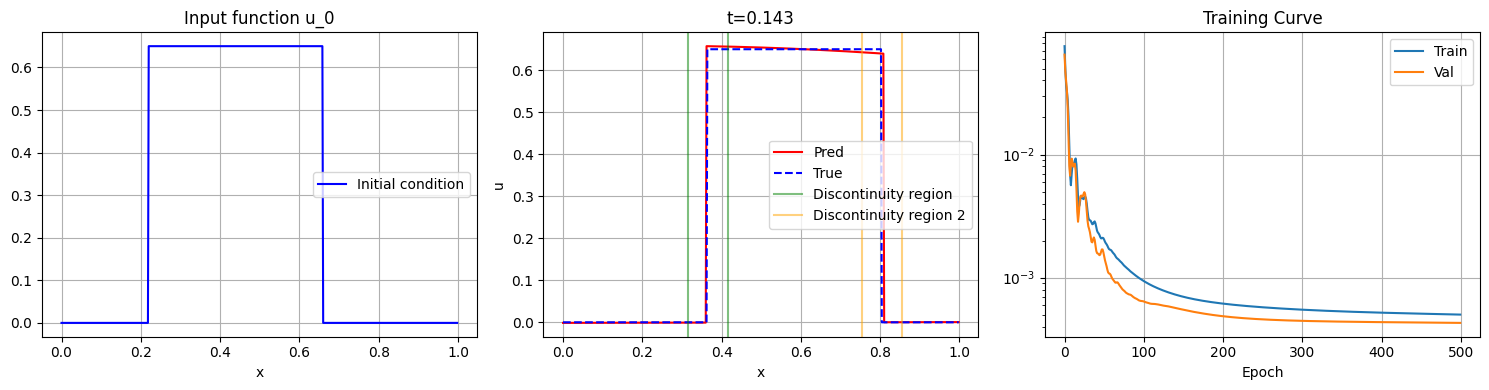

Total parameters: 458,241, trainable parameters: 458,241
L1 Loss (all points): 0.009, std: 0.005
L1 Loss (near discontinuity): 0.059, std: 0.035
L1 Loss (fair): 0.007, std: 0.004
L1 Loss (fair, near discontinuity): -0.022, std: 0.021


In [85]:
# Load the trained Lifted-DeepONet model
checkpoint = torch.load("checkpoints/cut_deeponet_checkpoint.pt", map_location=device, weights_only=False)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

input_data_test, output_data_test, discon_x_data_test = input_data[test_idx], output_data[test_idx], discon_x_data[test_idx]

l1_loss_all, l1_loss_near_discon_all, l1_loss_fair_all, l1_loss_fair_near_discon_all = error_analysis_dataset_test(model, input_data_test, output_data_test, x, t_domain, discon_x_data_test, window_size=int(0.05 * Nx))
show_results(model, checkpoint, input_data_test, output_data_test, x, t_domain, discon_x_data_test, sample_id=6)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}, trainable parameters: {trainable_params:,}")
print(f"L1 Loss (all points): {np.mean(l1_loss_all):.3f}, std: {np.std(l1_loss_all):.3f}")
print(f"L1 Loss (near discontinuity): {np.mean(l1_loss_near_discon_all):.3f}, std: {np.std(l1_loss_near_discon_all):.3f}")
print(f"L1 Loss (fair): {np.mean(l1_loss_fair_all):.3f}, std: {np.std(l1_loss_fair_all):.3f}")
print(f"L1 Loss (fair, near discontinuity): {np.mean(l1_loss_fair_near_discon_all):.3f}, std: {np.std(l1_loss_fair_near_discon_all):.3f}")